# Phase 4 — Realism, Validation & Out-of-Sample (detailed walkthrough)

This notebook explains, step by step, everything Phase 4 did and what we learned. Phases 1–2.5
established the strategy *in-sample* (PC core Sharpe 1.028, factor-beta 1.013). Phase 4 asks the
harder questions a sceptic would ask:

1. **Does it survive real trading costs?** (4a realism, §2)
2. **Can we reduce the cost drag sensibly?** (cost-optimisation sweep, §3)
3. **Is it free of lookahead bias** — i.e. does it secretly use the future? (4b audit, §4)
4. **Does it work on data it has never seen?** (4d out-of-sample forward test, §5)

Each section explains the idea, shows the real numbers, and plots the result.

## Contents
1. [Setup](#1)
2. [4a — Realism: real transaction costs](#2)
3. [Cost optimisation: which levers help](#3)
4. [4b — Lookahead-bias audit](#4)
5. [4d — True out-of-sample forward test](#5)
6. [Scoreboard & conclusion](#6)

<a id='1'></a>
## 1. Setup

Load the libraries and the per-phase result files (every number below comes from these).

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

_p = Path.cwd()
while _p != _p.parent and not (_p / "src" / "config.py").exists():
    _p = _p.parent
sys.path.insert(0, str(_p)); ROOT = _p
from src.config import PHASE2_DIR, PHASE2_5_DIR, PHASE4_DIR
from src.performance import compute_metrics

def monthly(path):
    return pd.read_parquet(path)["monthly_return"].astype(float)

def sharpe(path):
    return compute_metrics(monthly(path)).sharpe

plt.rcParams["figure.figsize"] = (9, 4)
print("ROOT:", ROOT)

ROOT: /Users/donkingyappy/Documents/Pairs Trading - Machine Learning/pairs-trading-ml


<a id='2'></a>
## 2. 4a — Realism: charging real transaction costs

The in-sample backtest was **frictionless** — it assumed you trade for free. Real trading isn't
free, so we add three frictions and re-run:

- **Transaction costs.** Every time we open or close a pair we cross the bid/ask spread on each
  leg. We charge **half the *actual* CRSP bid/ask spread** per leg, at entry and at exit. Using
  real per-name spreads matters because spreads were *much* wider in the early 2000s than today.
- **Borrow cost.** Shorting isn't free — we pay **35 bps/year** on the short leg.
- **Stop-loss.** A risk control: close a pair if it moves 3.5σ against us.

First, let's see *why* transaction costs hit the early years hardest — plot the median bid/ask
spread (in basis points) per year across the universe.

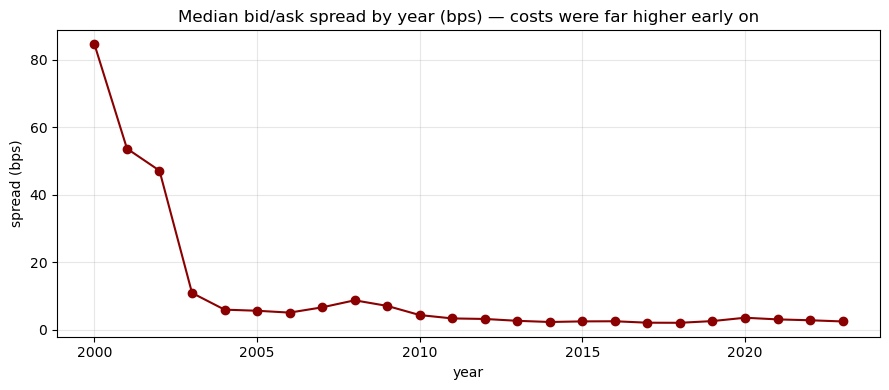

early-2000s ~54 bps vs recent ~3 bps


In [2]:
crsp = pd.read_parquet(ROOT / "data" / "crsp_daily.parquet", columns=["date","bid","ask"])
v = (crsp["bid"] > 0) & (crsp["ask"] > 0) & (crsp["ask"] >= crsp["bid"])
crsp = crsp[v].copy()
crsp["spread_bps"] = (crsp["ask"] - crsp["bid"]) / ((crsp["ask"] + crsp["bid"]) / 2) * 1e4
by_year = crsp.groupby(crsp["date"].dt.year)["spread_bps"].median()

ax = by_year.plot(marker="o", color="darkred")
ax.set_title("Median bid/ask spread by year (bps) — costs were far higher early on")
ax.set_ylabel("spread (bps)"); ax.set_xlabel("year"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("early-2000s ~%.0f bps vs recent ~%.0f bps" % (by_year.loc[2001], by_year.loc[2022]))

**The result.** Frictions cut the Sharpe by ~45%, but both strategies stay **net-positive** —
a real edge survives realistic costs.

In [3]:
rows = []
for name, base, real in [
    ("PC core",      PHASE2_DIR/"results"/"pc_core_monthly.parquet",
                     PHASE4_DIR/"results"/"pc_realism_monthly.parquet"),
    ("Factor-beta",  PHASE2_5_DIR/"results"/"factor_core_monthly.parquet",
                     PHASE4_DIR/"results"/"factor_realism_monthly.parquet"),
]:
    rows.append({"strategy": name, "frictionless": round(sharpe(base),3),
                 "net of costs": round(sharpe(real),3)})
tbl = pd.DataFrame(rows); print(tbl.to_string(index=False))

   strategy  frictionless  net of costs
    PC core         1.028         0.572
Factor-beta         1.013         0.578


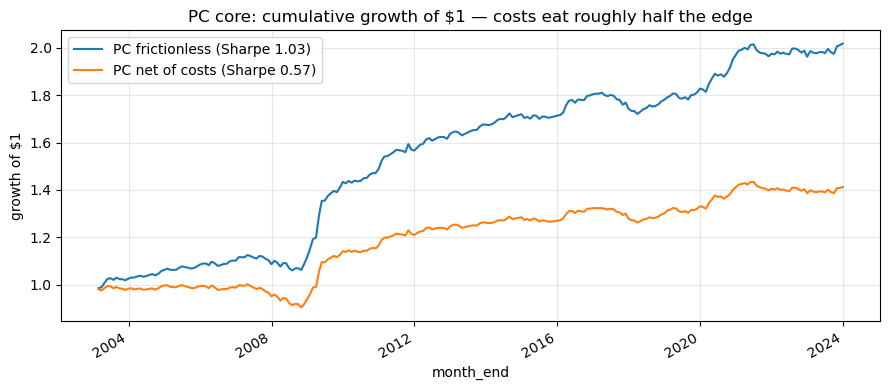

In [4]:
# Equity curves: frictionless vs net-of-cost (PC)
fric = (1 + monthly(PHASE2_DIR/"results"/"pc_core_monthly.parquet")).cumprod()
real = (1 + monthly(PHASE4_DIR/"results"/"pc_realism_monthly.parquet")).cumprod()
ax = fric.plot(label="PC frictionless (Sharpe 1.03)")
real.plot(ax=ax, label="PC net of costs (Sharpe 0.57)")
ax.set_title("PC core: cumulative growth of $1 — costs eat roughly half the edge")
ax.set_ylabel("growth of $1"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<a id='3'></a>
## 3. Cost optimisation — which levers actually help?

Net Sharpe is ~0.57. The drag comes from **churn** (most trades force-close at month-end for tiny
P&L that doesn't cover the spread) and **wide early-period spreads**. We tested principled levers:

- **passive** — use limit orders, crossing only *half* the spread instead of all of it.
- **nostop** — drop the 3.5σ stop (does it actually help, after the extra trades it causes?).
- **coint** — only trade cointegrated pairs (fewer trades).
- **entry2.5 / 3.0** — only trade bigger dislocations.

The bar chart ranks them by net Sharpe.

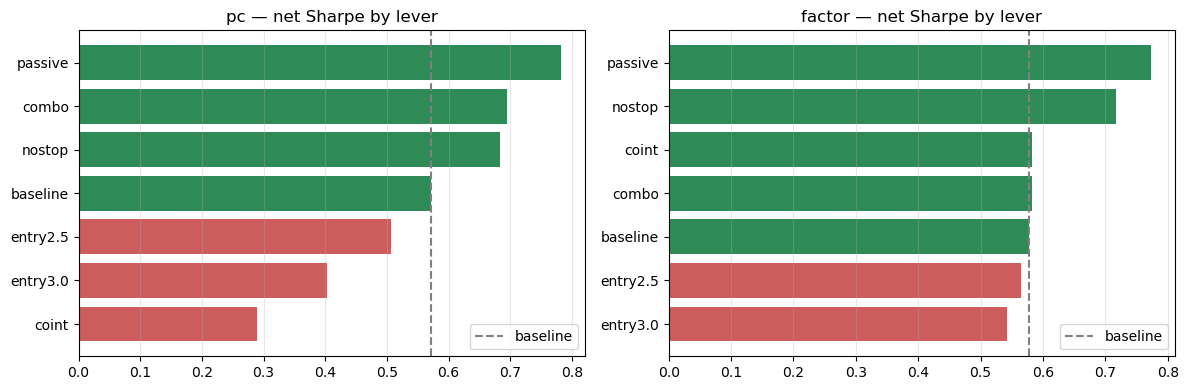

metric    lever  net_sharpe  ann_ret  ann_vol     mdd  n_trades
factor  passive       0.773   0.0246   0.0322 -0.0598     23520
factor   nostop       0.717   0.0230   0.0325 -0.0586     19044
factor    coint       0.583   0.0258   0.0456 -0.0941      7054
factor    combo       0.582   0.0335   0.0598 -0.0910      4513
factor baseline       0.578   0.0181   0.0320 -0.0656     23520
factor entry2.5       0.564   0.0227   0.0413 -0.1064     14624
factor entry3.0       0.543   0.0318   0.0611 -0.1428      8857
    pc  passive       0.782   0.0231   0.0297 -0.0751     37551
    pc    combo       0.694   0.0279   0.0409 -0.0690      7284
    pc   nostop       0.683   0.0204   0.0303 -0.0860     30050
    pc baseline       0.572   0.0166   0.0296 -0.0982     37551
    pc entry2.5       0.506   0.0177   0.0360 -0.1533     23632
    pc entry3.0       0.403   0.0180   0.0470 -0.1860     14604
    pc    coint       0.289   0.0084   0.0305 -0.1072     11316


In [5]:
co = pd.read_csv(PHASE4_DIR/"results"/"cost_optimization_summary.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, m in zip(axes, ["pc", "factor"]):
    sub = co[co.metric == m].sort_values("net_sharpe")
    colors = ["seagreen" if v >= sub[sub.lever=="baseline"].net_sharpe.iloc[0] else "indianred"
              for v in sub["net_sharpe"]]
    ax.barh(sub["lever"], sub["net_sharpe"], color=colors)
    ax.axvline(sub[sub.lever=="baseline"].net_sharpe.iloc[0], ls="--", color="grey", label="baseline")
    ax.set_title(f"{m} — net Sharpe by lever"); ax.legend(); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()
print(co.sort_values(["metric","net_sharpe"], ascending=[True,False]).to_string(index=False))

**What it says (same for both strategies):**
- **Passive execution is the #1 lever** (+~0.20): crossing less of the spread recovers most of the
  cost drag. It's not curve-fitting — it's a realistic execution assumption for a monthly strategy.
- **Dropping the stop is #2** (+0.11–0.14): the stop's extra round-trips cost more than the tail
  protection it buys, so it's *net-negative*.
- **The cointegration filter and higher entry thresholds HURT** — they discard too much alpha for
  the turnover they save.

So the best defensible operating point is **passive execution + no stop** (~0.78), not the filter.

<a id='4'></a>
## 4. 4b — Lookahead-bias audit

**The worry:** a backtest can secretly "use the future" (e.g. via a data-alignment bug), which
would inflate results and never work live. Instead of paper trading, we test this directly as a
black box (per the course guidance):

> Run the backtest over the full period **X→Y**, and again over a shorter period **X→Y′**.
> For every day they share, the target positions must be **identical**. If chopping off the
> future changes a *past* position, the strategy is reaching into the future — that's lookahead
> bias, by definition.

We ran it on both metrics across three cut dates (2009, 2013, 2017). The result:

In [6]:
la = pd.read_csv(PHASE4_DIR/"results"/"lookahead_summary.csv")
print(la.to_string(index=False))
print()
print("PASS" if la["passed"].all() else "FAIL",
      f"— {int(la['passed'].sum())}/{len(la)} checks, total mismatches:",
      int(la["mismatched_cells"].sum()))

metric   cut_date  passed  overlap_days  pairs  mismatched_cells  mismatched_days
    pc 2017-12-31    True          3776   2376                 0                0
    pc 2013-12-31    True          2768   2376                 0                0
    pc 2009-12-31    True          1762   2376                 0                0
factor 2017-12-31    True          3776   3866                 0                0
factor 2013-12-31    True          2768   3866                 0                0
factor 2009-12-31    True          1762   3866                 0                0

PASS — 6/6 checks, total mismatches: 0


**6/6 PASS, zero mismatches.** Truncating the end date never changed an earlier position, so
the look-ahead protections (t+1 execution, the rolling formation window, the lagged z-score,
point-in-time universe & delisting) all hold. The strategy is temporally honest.

<a id='5'></a>
## 5. 4d — True out-of-sample forward test (the real test)

Everything so far is *inside* 2003–2023 — and we even tuned hyperparameters on December-2023, so
2023 isn't a clean holdout. The only genuine test of "does it generalise?" is data from **after**
the development sample. We pulled current CRSP (CIZ tables, through 2025) and ran the **frozen**
strategies — no re-tuning — on **2024–2025**, comparing to the in-sample headlines.

A subtle but important lesson appears when we split by year:

In [7]:
def yr_sharpe(path, year):
    r = monthly(path); r.index = pd.to_datetime(r.index)
    s = r[r.index.year == year]
    return np.sqrt(12)*s.mean()/s.std() if len(s) > 1 and s.std() > 0 else float("nan")

fpc = PHASE4_DIR/"results"/"forward_pc_monthly.parquet"
ffa = PHASE4_DIR/"results"/"forward_factor_monthly.parquet"
rows = [
    {"strategy":"PC",         "in-sample":1.028, "OOS 2024":round(yr_sharpe(fpc,2024),3),
     "OOS 2025":round(yr_sharpe(fpc,2025),3), "OOS full":round(sharpe(fpc),3)},
    {"strategy":"Factor-beta","in-sample":1.013, "OOS 2024":round(yr_sharpe(ffa,2024),3),
     "OOS 2025":round(yr_sharpe(ffa,2025),3), "OOS full":round(sharpe(ffa),3)},
]
print(pd.DataFrame(rows).to_string(index=False))

   strategy  in-sample  OOS 2024  OOS 2025  OOS full
         PC      1.028     0.157     1.404     0.858
Factor-beta      1.013    -0.457     0.466     0.117


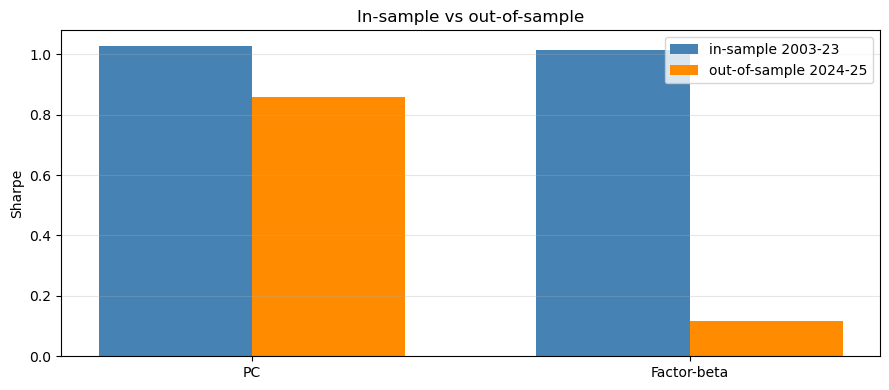

In [8]:
# in-sample vs out-of-sample (full window) bar chart
labels = ["PC", "Factor-beta"]
insample = [1.028, 1.013]; oos = [sharpe(fpc), sharpe(ffa)]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots()
ax.bar(x-w/2, insample, w, label="in-sample 2003-23", color="steelblue")
ax.bar(x+w/2, oos, w, label="out-of-sample 2024-25", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("Sharpe"); ax.set_title("In-sample vs out-of-sample"); ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

**Findings:**
1. **PC generalises** — its out-of-sample Sharpe (~0.86) is close to the in-sample 1.028, and in
   2025 it actually *exceeded* it (~1.40). Strong evidence the edge is real, not an artefact.
2. **Factor-beta does NOT generalise well** (~0.12) — a reversal: it was the *sturdier* metric
   under in-sample robustness tests, but the *weaker* one on unseen data. A caution against
   trusting in-sample robustness alone.
3. **Strong regime dependence** — both were weak in calm, trending 2024 and recovered in 2025
   (the strategy needs dislocation/dispersion to work).

**Methodological lesson:** if we'd looked at 2024 *alone* (PC ≈ 0.16) we'd have wrongly concluded
"it failed." Only the fuller 23-month window reveals PC actually holds. A single short
out-of-sample window is unreliable.

<a id='6'></a>
## 6. Scoreboard & conclusion

| Stage | PC | Factor-beta |
|---|---:|---:|
| In-sample (frictionless) | 1.028 | 1.013 |
| Net of realistic costs | 0.572 | 0.578 |
| Net + passive execution | 0.782 | 0.773 |
| Lookahead audit | PASS | PASS |
| Out-of-sample (2024–25) | **0.858** | 0.117 |

**The story.** The paper replicates (PC 1.028) and an independent factor-beta metric corroborates
it (1.013). The strategy is bias-free, keeps a positive Sharpe after realistic costs (~0.57,
recoverable to ~0.78 with passive execution and no stop), and — most importantly — **PC genuinely
generalises out-of-sample (0.858)**. Honest caveats: performance is regime-dependent, and the
factor-beta extension generalises worse than PC despite looking sturdier in-sample.

This is the full Phase 4 picture: not just "it worked in a backtest," but *stress-tested,
audited for bias, and validated on data it had never seen.*